### Intigrating planning with Agents

- Task planning and progress tracking
- Efficient state merging with reducer functions


Why we need planning?

- Many agents use TODO/Planning lists as a critical navigation tool for steering through long-running, complex tasks. 

- Each TODO/Planning item contains two key components: content (a short, specific task description) and status (pending, in_progress, or completed).

- Agents become vulnerable to drifting off-topic or forgetting earlier objectives during lengthy conversations or complicated tasks. By continuously rewriting and updating the TODO/Planning list, agents effectively recite their objectives at the end of the context, helping to stay focused on task and prevent mission drift.

In [1]:
from dotenv import load_dotenv
load_dotenv()
import os

In [2]:
! uv pip install langgraph langchain -U

Using Python 3.11.13 environment at: /Users/aritrasen/Documents/code/agents_observability/.venv
Resolved 32 packages in 261ms                                        
Audited 32 packages in 0.09ms


In [3]:
from typing import Annotated , Literal , NotRequired 
from typing_extensions import TypedDict
from langchain.agents.middleware import AgentState

/Users/aritrasen/Documents/code/agents_observability/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Creation planning class and Agent State

In [4]:
class Planning(TypedDict):
    """Schema for planning agent state.
    Attributes:
        current_task (str): The current task being worked on.
        status:  ["pending", "in_progress", "completed"] - The status of the current task.
    """
    current_task : str
    status : Literal["pending", "in_progress", "completed"]

class AgentStateWithPlanning(AgentState):
    """Agent state with planning capabilities.
    Attributes:
        planning: Planning information for the agent.
    """
    planning: NotRequired[list[Planning]]

### Instructions for planning

In [5]:
# ADOPTED FROM : https://github.com/langchain-ai/deep-agents-from-scratch/blob/main/src/deep_agents_from_scratch/prompts.py 

WRITE_PLANNING_DESCRIPTION = """Create and manage structured task lists for tracking progress through complex workflows.

## When to Use
- Multi-step or non-trivial tasks requiring coordination
- When user provides multiple tasks or explicitly requests todo list  
- Avoid for single, trivial actions unless directed otherwise

## Structure
- Maintain one list containing multiple todo objects (content, status, id)
- Use clear, actionable content descriptions
- Status must be: pending, in_progress, or completed

## Best Practices  
- Only one in_progress task at a time
- Mark completed immediately when task is fully done
- Always send the full updated list when making changes
- Prune irrelevant items to keep list focused

## Progress Updates
- Call TodoWrite again to change task status or edit content
- Reflect real-time progress; don't batch completions  
- If blocked, keep in_progress and add new task describing blocker

## Parameters
- todos: List of Planning items with content and status fields

## Returns
Updates agent state with new planning list."""

PLANNING_USAGE_INSTRUCTIONS = """Based upon the user's request:
1. Use the write_planning tool to create PLANNING at the start of a user request, per the tool description.
2. After you accomplish a PLANNIG task, use the read_planning to read the PLANNING in order to remind yourself of the plan. 
3. Reflect on what you've done and the PLANNING.
4. Mark you task as completed, and proceed to the next PLANNING.
5. Continue this process until you have completed all PLANNING tasks.

IMPORTANT: Always create a research plan of PLANNINGs and conduct research following the above guidelines for ANY user request.
IMPORTANT: Aim to batch research tasks into a *single PLANNING* in order to minimize the number of PLANNINGs you have to keep track of.
"""

### Define Write planning and Read planning tools

In [6]:
from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command


@tool(description=WRITE_PLANNING_DESCRIPTION,parse_docstring=True)
def write_planning(
    plannings: list[Planning], tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Create or update the agent's PLANNING list for task planning and tracking.

    Args:
        plannings: List of PLANNINGs items with content and status
        tool_call_id: Tool call identifier for message response

    Returns:
        Command to update agent state with new PLANNING list
    """
    return Command(
        update={
            "plannings": plannings,
            "messages": [
                ToolMessage(f"Updated planning list to {plannings}", tool_call_id=tool_call_id)
            ],
        }
    )


@tool(parse_docstring=True)
def read_plannings(
    state: Annotated[AgentStateWithPlanning, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> str:
    """Read the current PLANNING list from the agent state.

    This tool allows the agent to retrieve and review the current PLANNING list
    to stay focused on remaining tasks and track progress through complex workflows.

    Args:
        state: Injected agent state containing the current PLANNING list
        tool_call_id: Injected tool call identifier for message tracking

    Returns:
        Formatted string representation of the current PLANNING list
    """
    plannings = state.get("plannings", [])
    if not plannings:
        return "No PLANNINGs currently in the list."

    result = "Current PLANNING List:\n"
    for i, todo in enumerate(plannings, 1):
        status_emoji = {"pending": "⏳", "in_progress": "🔄", "completed": "✅"}
        emoji = status_emoji.get(plannings["status"], "❓")
        result += f"{i}. {emoji} {plannings['content']} ({plannings['status']})\n"

    return result.strip()

### LLM Initialization

In [7]:
from langchain_openai import ChatOpenAI

# Now you can access your environment variables using os.environ
os.environ['OPENAI_API_KEY'] = os.environ.get("OPENAI_API_KEY")
os.environ['TAVILY_API_KEY'] = os.environ.get("TAVILY_API_KEY")


llm = ChatOpenAI(model="gpt-5.4")

In [8]:
llm.invoke('Hi there!')

AIMessage(content='Hi! How can I help?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 9, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DR8vFSIv5g2rUw6raWF0oAzJTIuvr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d5bcb-02ca-71f1-b042-f7c6cb2c0730-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 10, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

### Creation to websearch tools for Research Agent

In [9]:
from typing import Annotated, List, Tuple, Union

from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults(max_results=2)

/var/folders/57/y3hsdcy135b1wr5gzcw3b3kr0000gn/T/ipykernel_49155/2933932211.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=2)


In [10]:
result = tavily_tool.invoke({"query": 'What is LangGraph?'})
result

[{'title': 'What is LangGraph - GeeksforGeeks',
  'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/',
  'content': 'Interview Prep\n\n Python for Machine Learning\n Machine Learning with R\n Machine Learning Algorithms\n EDA\n Math for Machine Learning\n Machine Learning Interview Questions\n ML Projects\n Deep Learning\n NLP\n Computer vision\n Data Science\n Artificial Intelligence\n\n# What is LangGraph?\n\nLast Updated : 12 Dec, 2025\n\nLangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions.',
  'score': 0.94301796},
 {'title': "Introduction to LangGraph: A Beginner's Guide - Medium",
  'url': 'https://medium.com/@cplog/introduction-to-langgraph-a-beginners-guide-14f9be027141',
  'content': '## What is LangGr

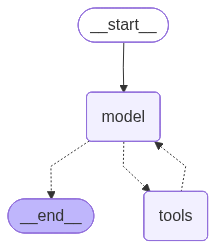

In [11]:
from IPython.display import Image, display
from langchain_core.tools import tool
from langchain.agents import create_agent


# Mock search tool
@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    docs = tavily_tool.invoke({"query": query})
    web_results = "\n".join([d["content"] for d in docs])
    return web_results

# Create agent using create_react_agent directly
tools = [write_planning, web_search, read_plannings]

# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """IMPORTANT: Just make a single call to the web_search tool and use the result provided by the tool to answer the user's question."""

# Create agent
agent = create_agent(
    llm,
    tools,
    system_prompt=PLANNING_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + SIMPLE_RESEARCH_INSTRUCTIONS,
    state_schema=AgentStateWithPlanning,
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

### Testing the Research Agent with Planning

In [12]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me a short summary of the Agent 2 Agent Protocol (A2A).",
            }
        ],
        "plannings": [],
    }
)

In [13]:

for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me a short summary of the Agent 2 Agent Protocol (A2A).
================================== Ai Message ==================================
Tool Calls:
  write_planning (call_CIu9xBYSwSSEQSPOm2Yg0YrS)
 Call ID: call_CIu9xBYSwSSEQSPOm2Yg0YrS
  Args:
    plannings: [{'current_task': 'Gather concise information on the Agent 2 Agent Protocol (A2A) and produce a short summary for the user', 'status': 'in_progress'}]
================================= Tool Message =================================
Name: write_planning

Updated planning list to [{'current_task': 'Gather concise information on the Agent 2 Agent Protocol (A2A) and produce a short summary for the user', 'status': 'in_progress'}]
================================== Ai Message ==================================
Tool Calls:
  read_plannings (call_N0Gq2qYbjIyNHerKeibDaNw2)
 Call ID: call_N0Gq2qYbjIyNHerKeibDaNw2
  Args:
================================